In [3]:
import pickle
with open("pre_split_data.pkl", "rb") as f:
    X, y, categorical, numerical = pickle.load(f)

For segmentation model, we use K-means clustering. 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# use frequency encoding 
X_enc = X.copy()
for col in categorical:
    freq = X_enc[col].value_counts() / len(X_enc)
    X_enc[col] = X_enc[col].map(freq)
# scale numerical features
scaler = StandardScaler()
X_enc[numerical] = scaler.fit_transform(X_enc[numerical])

In [7]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_enc)
remaining_columns = X_enc.columns[selector.get_support()]
print(remaining_columns)
print(len(remaining_columns))

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed',
       'fill inc questionnai

In [8]:

# Scale all columns using standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

We first run a K-Means directly on scaled data.

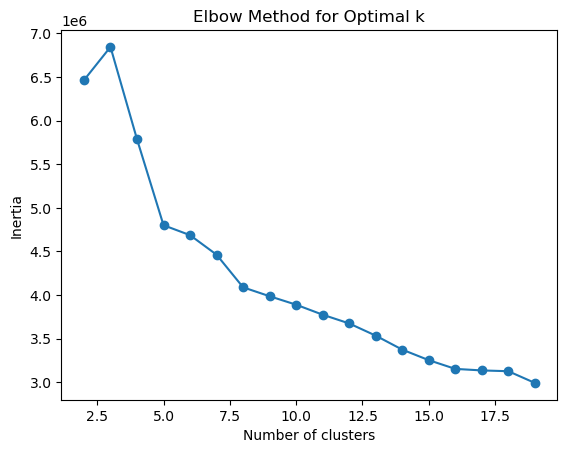

In [9]:
inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

Next we attempt a TruncatedSVD dimension reduction since our data is very sparse.
We find an acceptable number of components by looking at the exxplained variance. 

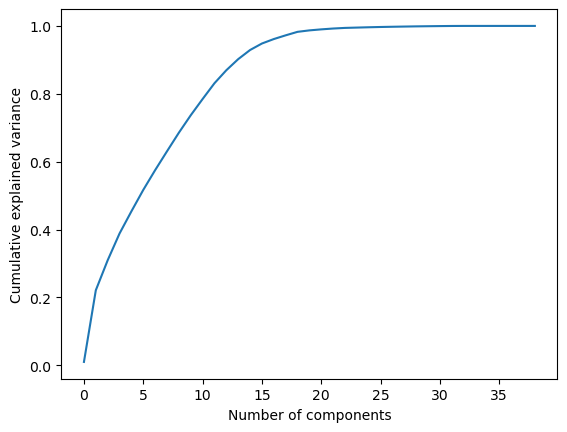

In [11]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=39, random_state=42)
X_svd = svd.fit_transform(X_filtered)

explained_ratio = svd.explained_variance_ratio_
cumulative_variance = explained_ratio.cumsum()

import matplotlib.pyplot as plt
plt.plot(cumulative_variance)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

In [14]:
# TruncatedSVD shows that 15 components explain over 90% of the variance, so we can use that for clustering
svd = TruncatedSVD(n_components=10, random_state=42)    
X_svd = svd.fit_transform(X_filtered)

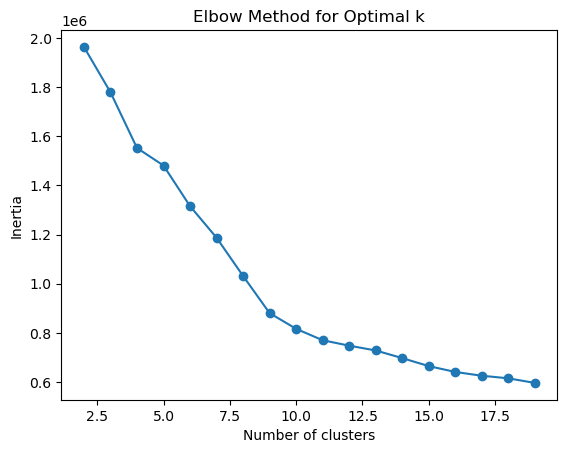

In [15]:
inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_svd)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

K-Means on Truncated SVD reduced data and on scaled only data both show an "elbow" at number of clsuters = 8. 
We now train a K-Means with k = 8 to get cluster assignment.

In [19]:
k = 3
kmeans = KMeans(n_clusters=k, 
                n_init=10,
                random_state=27)
clusters = kmeans.fit_predict(X_svd)  
X['cluster'] = clusters

In [20]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_idx = np.random.choice(len(X_svd), size=10000, replace=False)
score = silhouette_score(X_svd[sample_idx], clusters[sample_idx])
print(f"Silhouette score (sample): {score:.3f}")

Silhouette score (sample): 0.262


Given the cluster labels, we group data by their cluster.
We can calculate the mean values on the numerical columns

In [21]:
# need a different split of num vs cat

numerical_summary  = X.groupby('cluster')[numerical].mean()
print(numerical_summary)

               age  detailed industry recode  detailed occupation recode  \
cluster                                                                    
0         7.515672                  0.000936                    0.002170   
1        38.306736                 30.557916                   22.454521   
2        53.690977                  1.136951                    0.930210   

         wage per hour       sex  member of a labor union  capital gains  \
cluster                                                                    
0             0.009044  0.532206                -0.000021       0.287797   
1           112.349225  0.532970                -0.132287     776.216593   
2             0.207369  0.323248                 0.000137     203.974768   

         capital losses  dividends from stocks       weight  \
cluster                                                       
0              0.076689               0.320694  1670.665289   
1             63.563336             168.776960  1

In [22]:
X['cluster'].value_counts()

cluster
1    98332
2    50967
0    46995
Name: count, dtype: int64

numerical features, year doesn't matter, reduce to 16 features, plot 6 bars one for each cluster. 
Each subplot is one feature

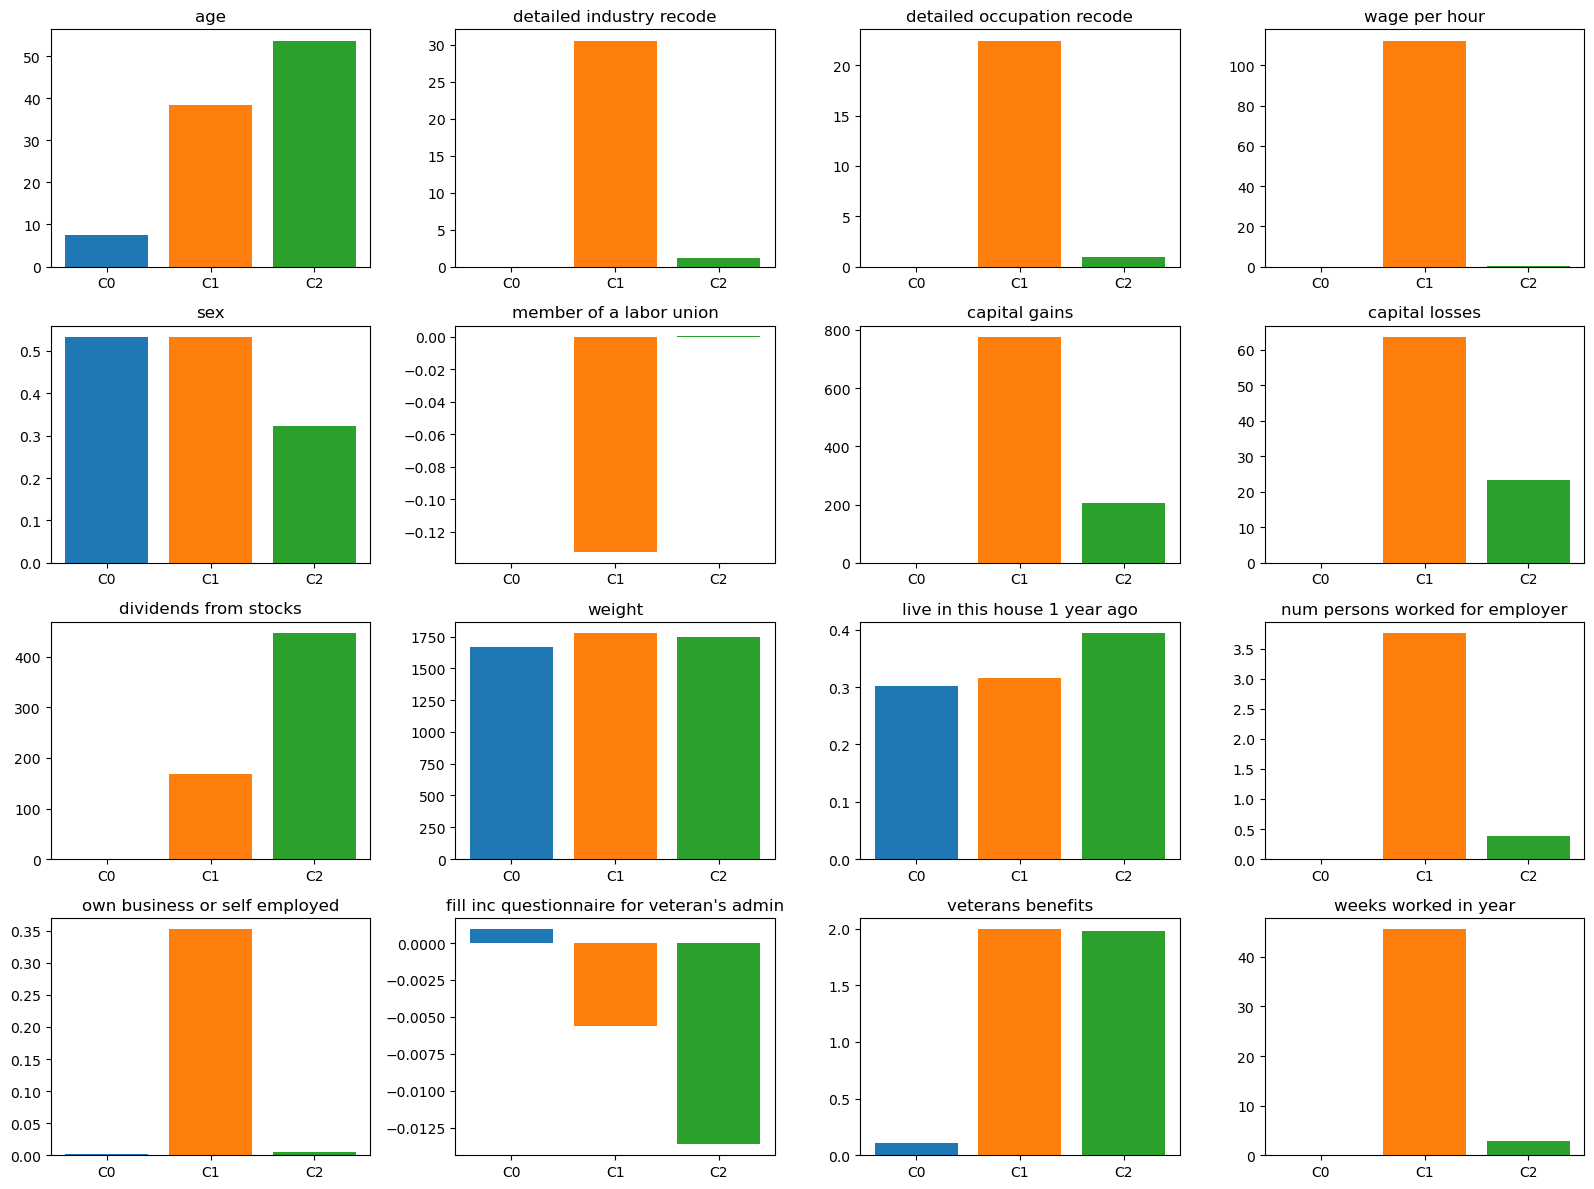

In [23]:
import matplotlib.pyplot as plt
import numpy as np

features = numerical_summary.drop(columns=['year']).columns
n_clusters = numerical_summary.shape[0]

# choose colors for each cluster (length = n_clusters)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # up to 6 clusters

fig, axes = plt.subplots(4, 4, figsize=(16,12))
axes = axes.flatten()

x = np.arange(n_clusters)

for i, feature in enumerate(features):
    ax = axes[i]
    
    vals = numerical_summary[feature]
    
    # assign color to each bar
    bar_colors = colors[:n_clusters]
    
    ax.bar(x, vals, color=bar_colors)
    
    ax.set_title(feature)
    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in range(n_clusters)])
    
plt.tight_layout()
plt.show()

Ctegorical features can will be plotted separately as heatmaps, each has value * cluster

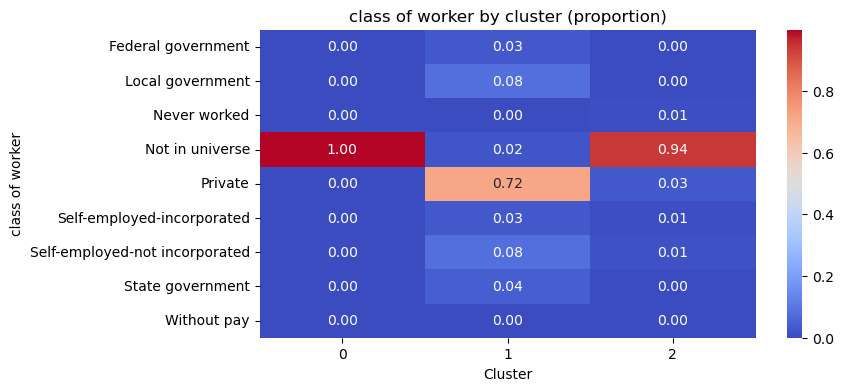

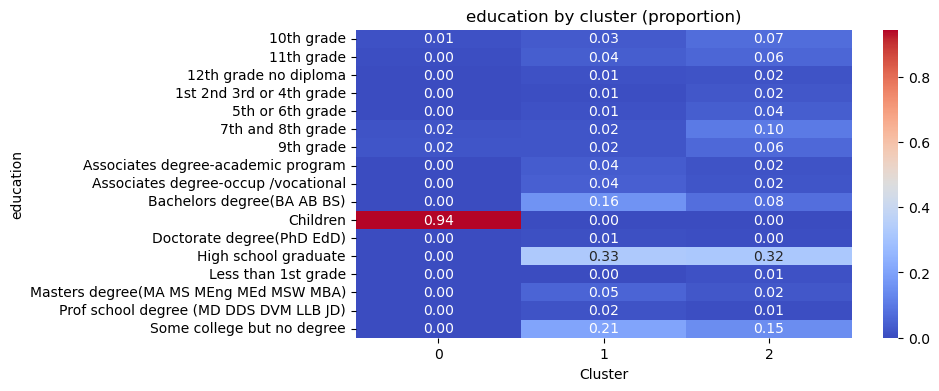

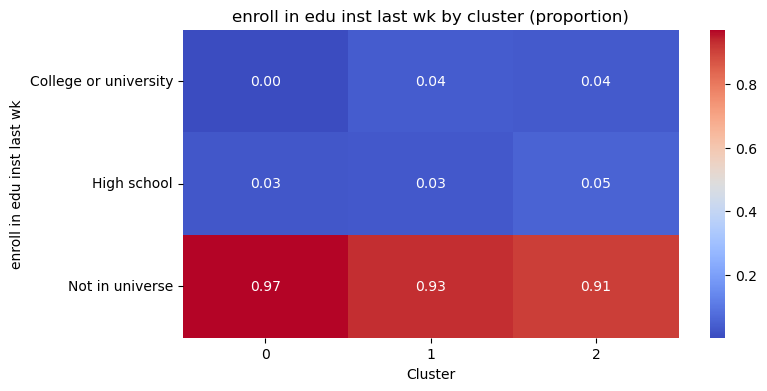

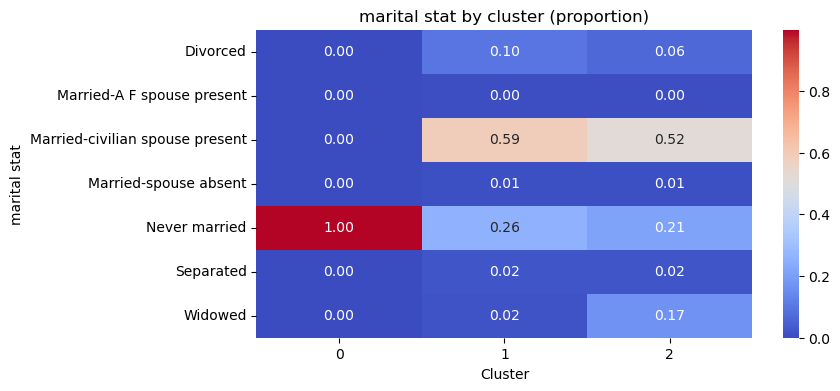

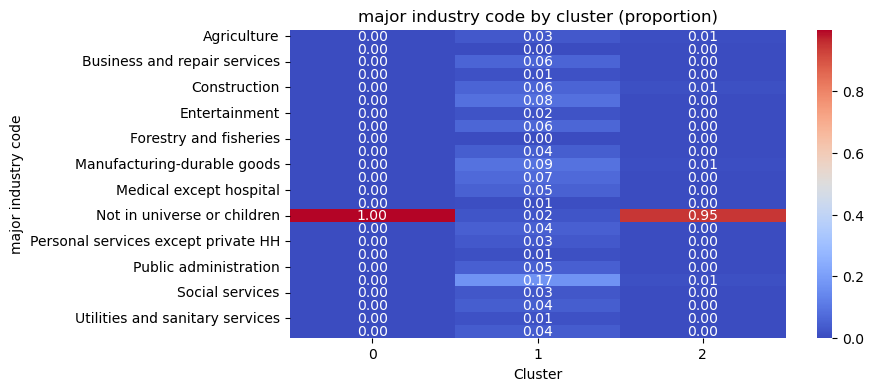

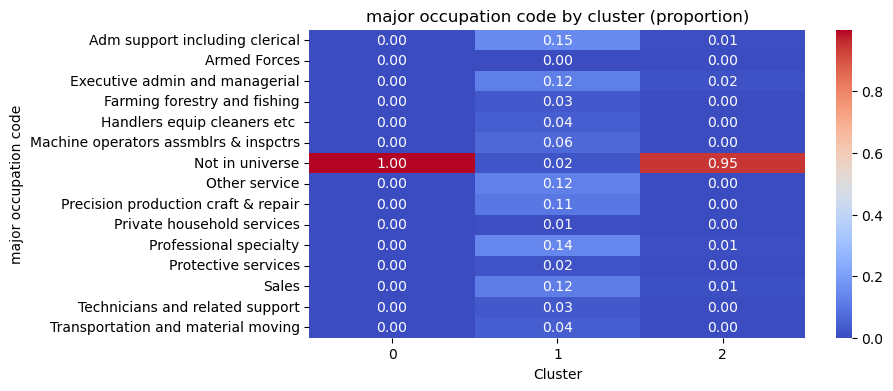

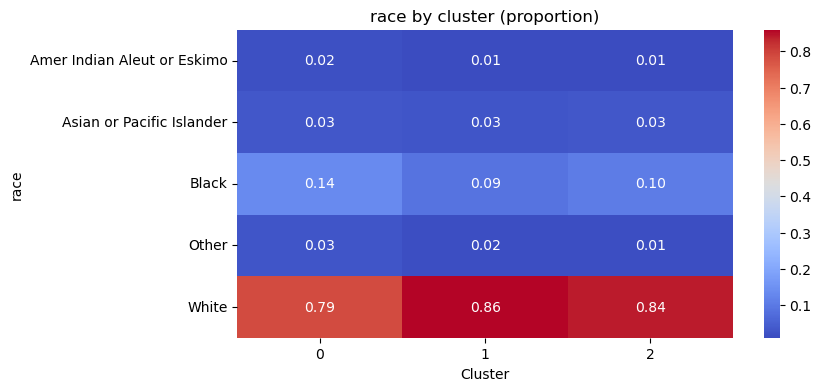

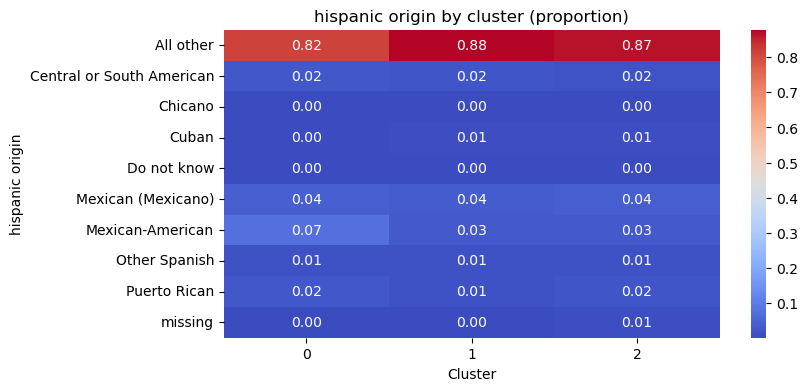

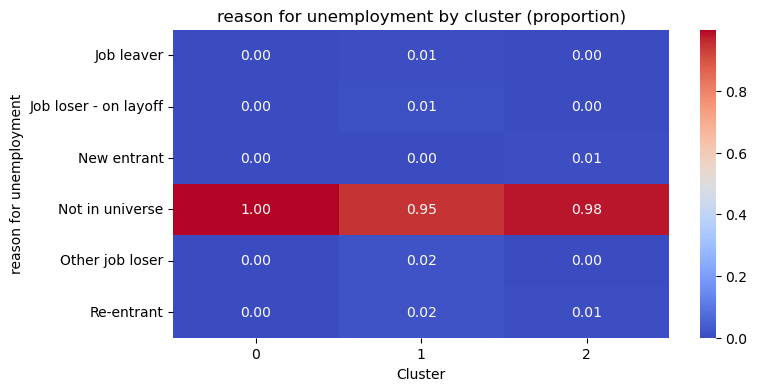

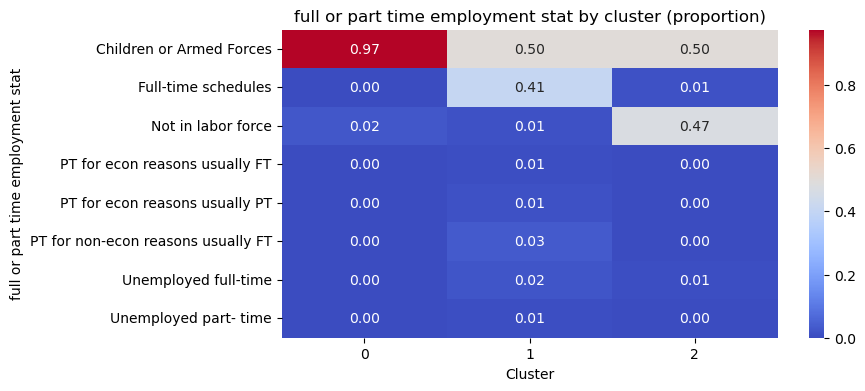

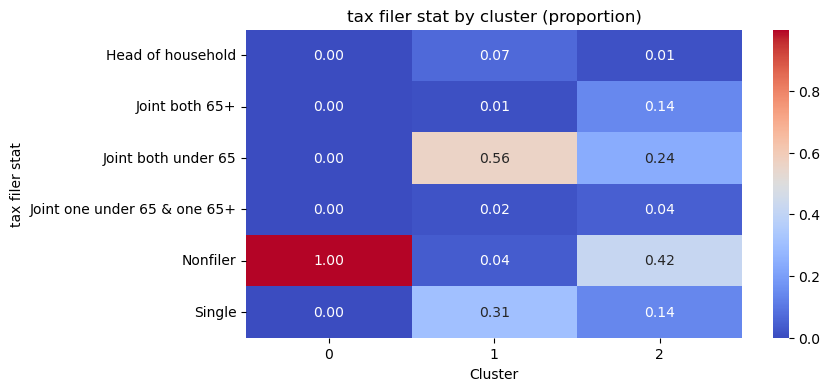

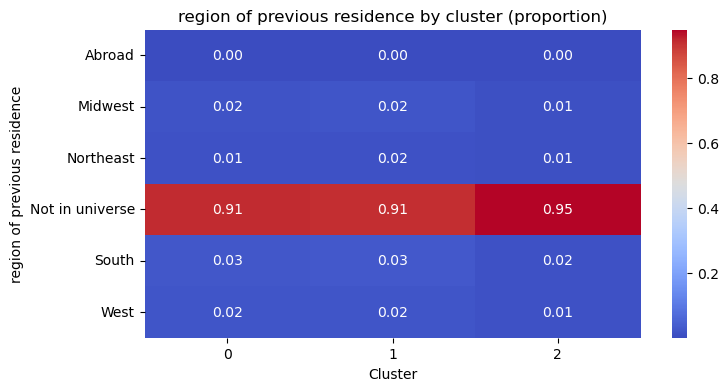

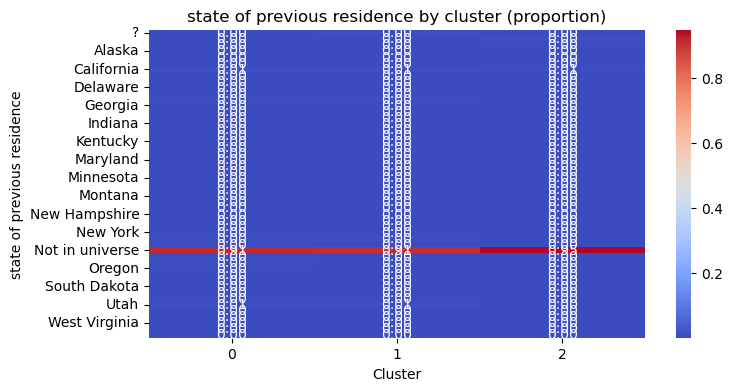

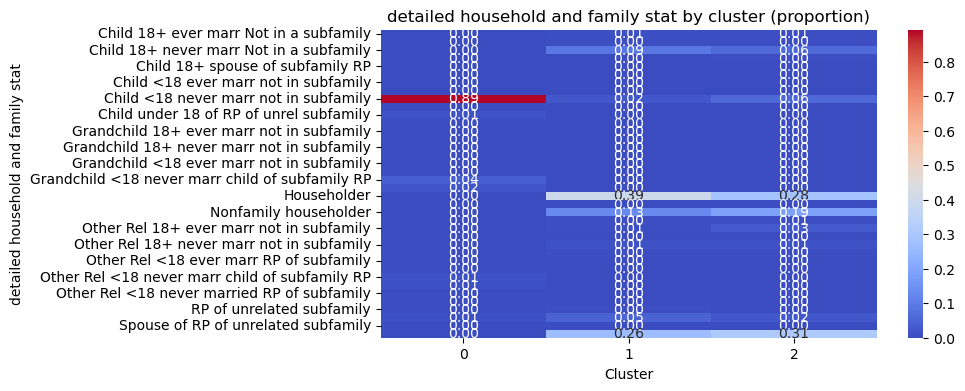

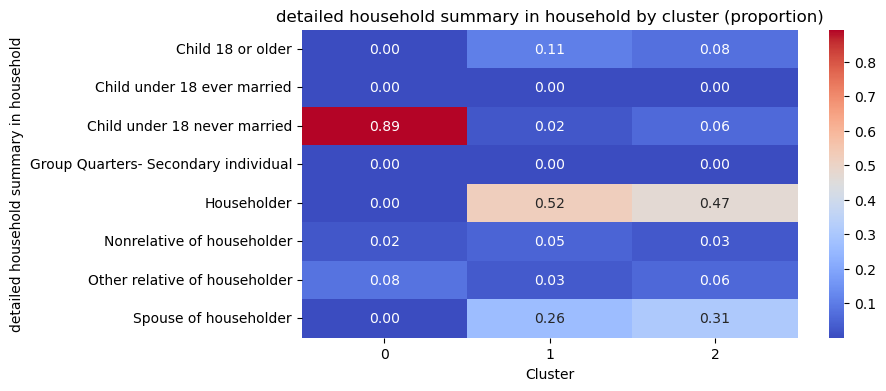

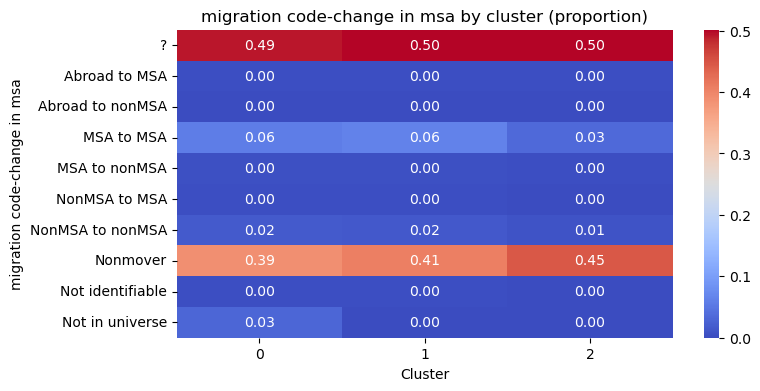

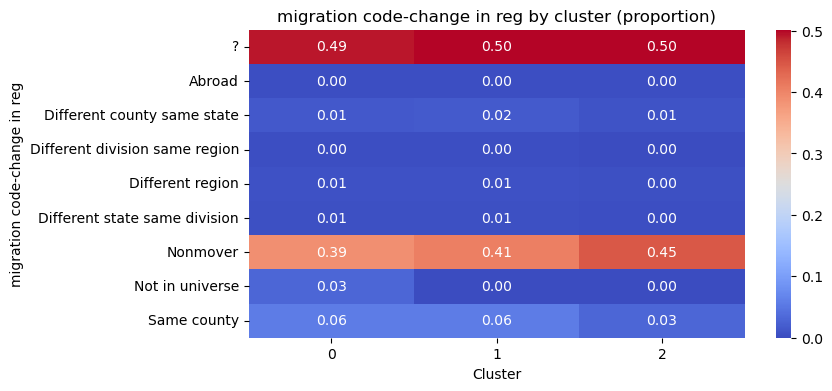

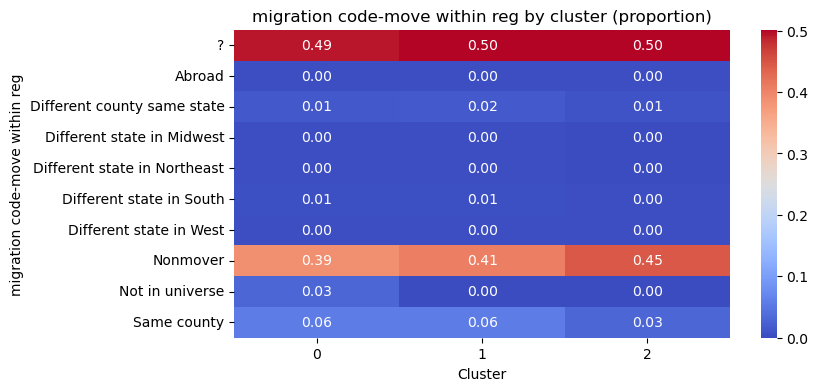

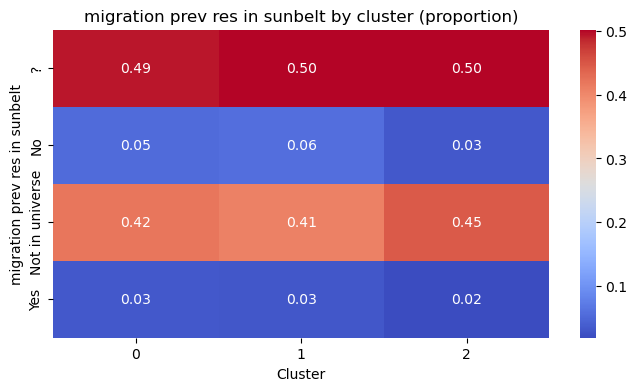

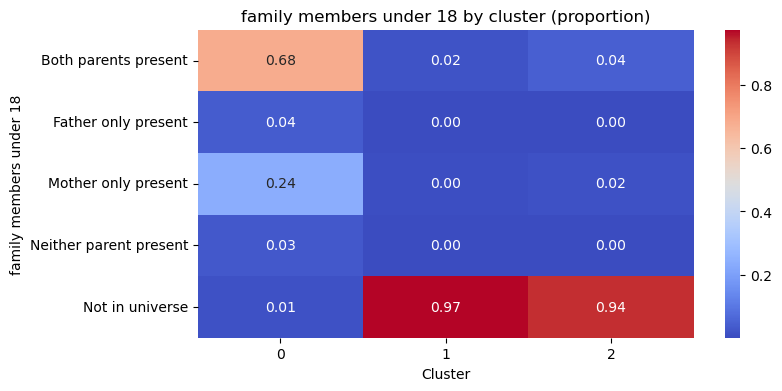

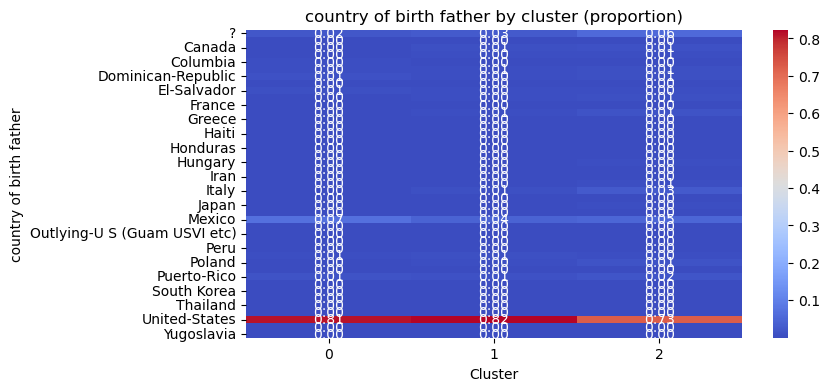

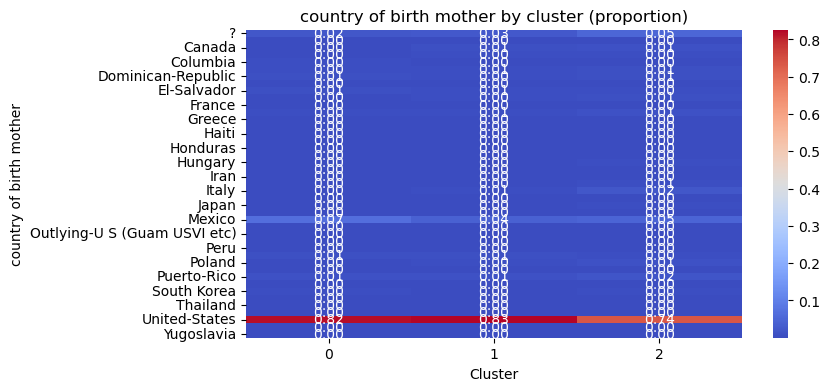

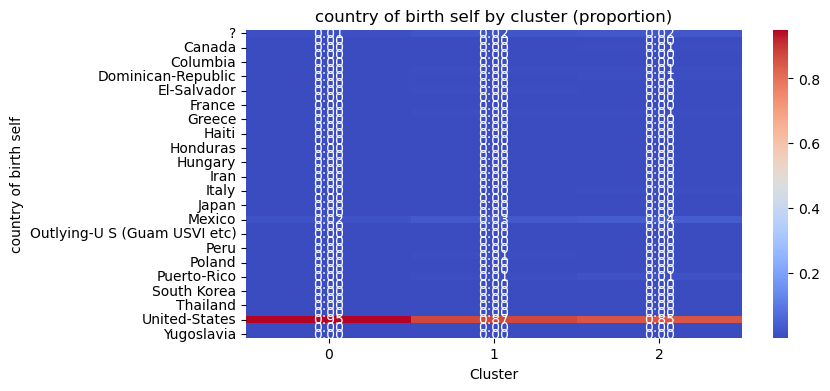

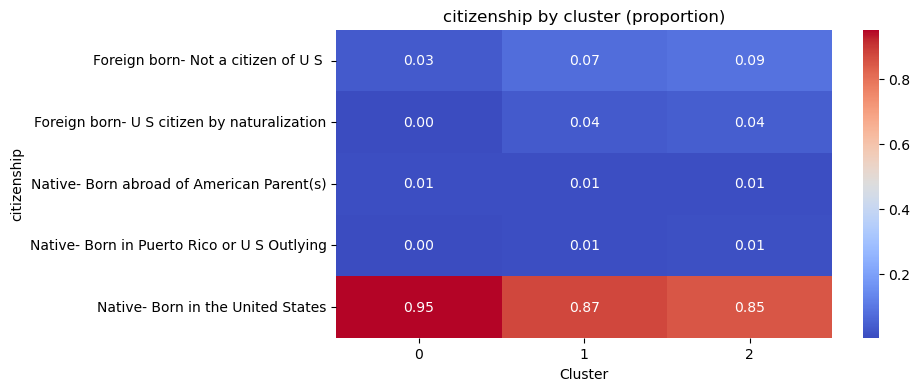

In [26]:
import seaborn as sns
for feature in categorical:
    ct = pd.crosstab(X[feature], X['cluster'], normalize='columns')
    plt.figure(figsize=(8,4))
    sns.heatmap(ct, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'{feature} by cluster (proportion)')
    plt.ylabel(feature)
    plt.xlabel('Cluster')
    plt.show()